## Notebook to reproduce Fig 1

In [12]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy, pylab
import bilby
import os
from scipy.signal import butter, filtfilt
from scipy import signal
import matplotlib.gridspec as gridspec


import seaborn as sns
sns.set_context('talk') 


sns.set_theme(font_scale=2)
sns.set_palette('colorblind')
sns.set_style('ticks')

pylab.rcParams.update(
    {
        'text.usetex': False,
        'font.family': 'stixgeneral',
        'mathtext.fontset': 'stix',
        'axes.grid' : True,
        'grid.linestyle' : '--',
        'grid.color' : '#bbbbbb'

    }
)

pylab.rcParams['axes.linewidth'] = 1

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

In [13]:
#Settings

sampling_frequency = 1024  # Hz
duration = 8  # seconds
start_time = 1384782882.634277105 #2023-11-23T13:54:24
ifos = ['H1', 'L1']

# Generate time array
num_samples = int(sampling_frequency * duration)
time_array = start_time + numpy.arange(num_samples) / sampling_frequency

In [14]:
geocent_time = 1384782888.6189551

In [15]:
# Open whitened data (by BayesWave) 

bayeswave = '../Results/Results_for_Fig1'

whitened = {'H1': os.path.join(bayeswave, 'BayesWave_whitened_data_H1.dat'),
                 'L1': os.path.join(bayeswave, 'BayesWave_whitened_data_L1.dat')}
                 

In [16]:
#Open BayesWave reconstruction from the same folder

bayeswave_reconstruction = {'H1': os.path.join(bayeswave, 'BayesWave_signal_median_time_domain_waveform_H1.dat'),
                            'L1': os.path.join(bayeswave, 'BayesWave_signal_median_time_domain_waveform_L1.dat')}

# Load the data using numpy.genfromtxt
BW_summary_data = {
    ifo: numpy.genfromtxt(bayeswave_reconstruction[ifo])
    for ifo in bayeswave_reconstruction
}

# Create structured summary dictionary
bw_summary_data = {
    ifo: {
        "time": time_array,
        "median": BW_summary_data[ifo][:, 1],
        "lower90": BW_summary_data[ifo][:, 4],
        "upper90": BW_summary_data[ifo][:, 5],
        "lower50": BW_summary_data[ifo][:, 2],
        "upper50": BW_summary_data[ifo][:, 3],
    }
    for ifo in BW_summary_data
}

In [17]:
#Open cWB-BBH reconstruction

cwb_reconstruction = {'H1': '../Results/Results_for_Fig1/cWB_H1_wf_signal.dat',
                       'L1': '../Results/Results_for_Fig1/cWB_L1_wf_signal.dat'}  

cwb_data = {
    ifo: numpy.genfromtxt(cwb_reconstruction[ifo], names=['time', 'amp_cwb_rec'])
    for ifo in ifos
}

In [18]:
# Open median combined waveform from combined samples

bilby_summary_data_all = numpy.genfromtxt("../Results/Results_for_Fig1/median_combined_waveform_with_90pct_uncertainty.dat", names=True)


bilby_summary_data = {
    ifo: {
        "time": bilby_summary_data_all[f"{ifo}_time"],
        "lower": bilby_summary_data_all[f"{ifo}_lower"],
        "median": bilby_summary_data_all[f"{ifo}_median"],
        "upper": bilby_summary_data_all[f"{ifo}_upper"],
    }
    for ifo in ifos
}

In [19]:
# Design a Butterworth lowpass filter for the data

def lowpass_filter(data, lowpass_frequency=256, sampling_frequency=1024, order=4):
    nyquist = 0.5 * sampling_frequency
    normal_cutoff = lowpass_frequency / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Load and filter data
whitened_data = {
    ifo: {
        "time": time_array,
        "strain": lowpass_filter(numpy.genfromtxt(whitened[ifo]))
    }
    for ifo in ifos
}

In [20]:
# Wavelet settings for spectrogram

max_cwt_frequency = 256  # Hz
min_cwt_frequency = 20   # Hz
w = 4
target_sampling_rate = 1024  # Hz
cwt_frequencies = numpy.linspace(min_cwt_frequency, max_cwt_frequency, 300)
widths = w * target_sampling_rate / (2 * cwt_frequencies * numpy.pi)

/tmp/ipykernel_844178/2965645960.py:71: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  cwt_matrix = signal.cwt(whitened, signal.morlet2, widths=widths, w=w)


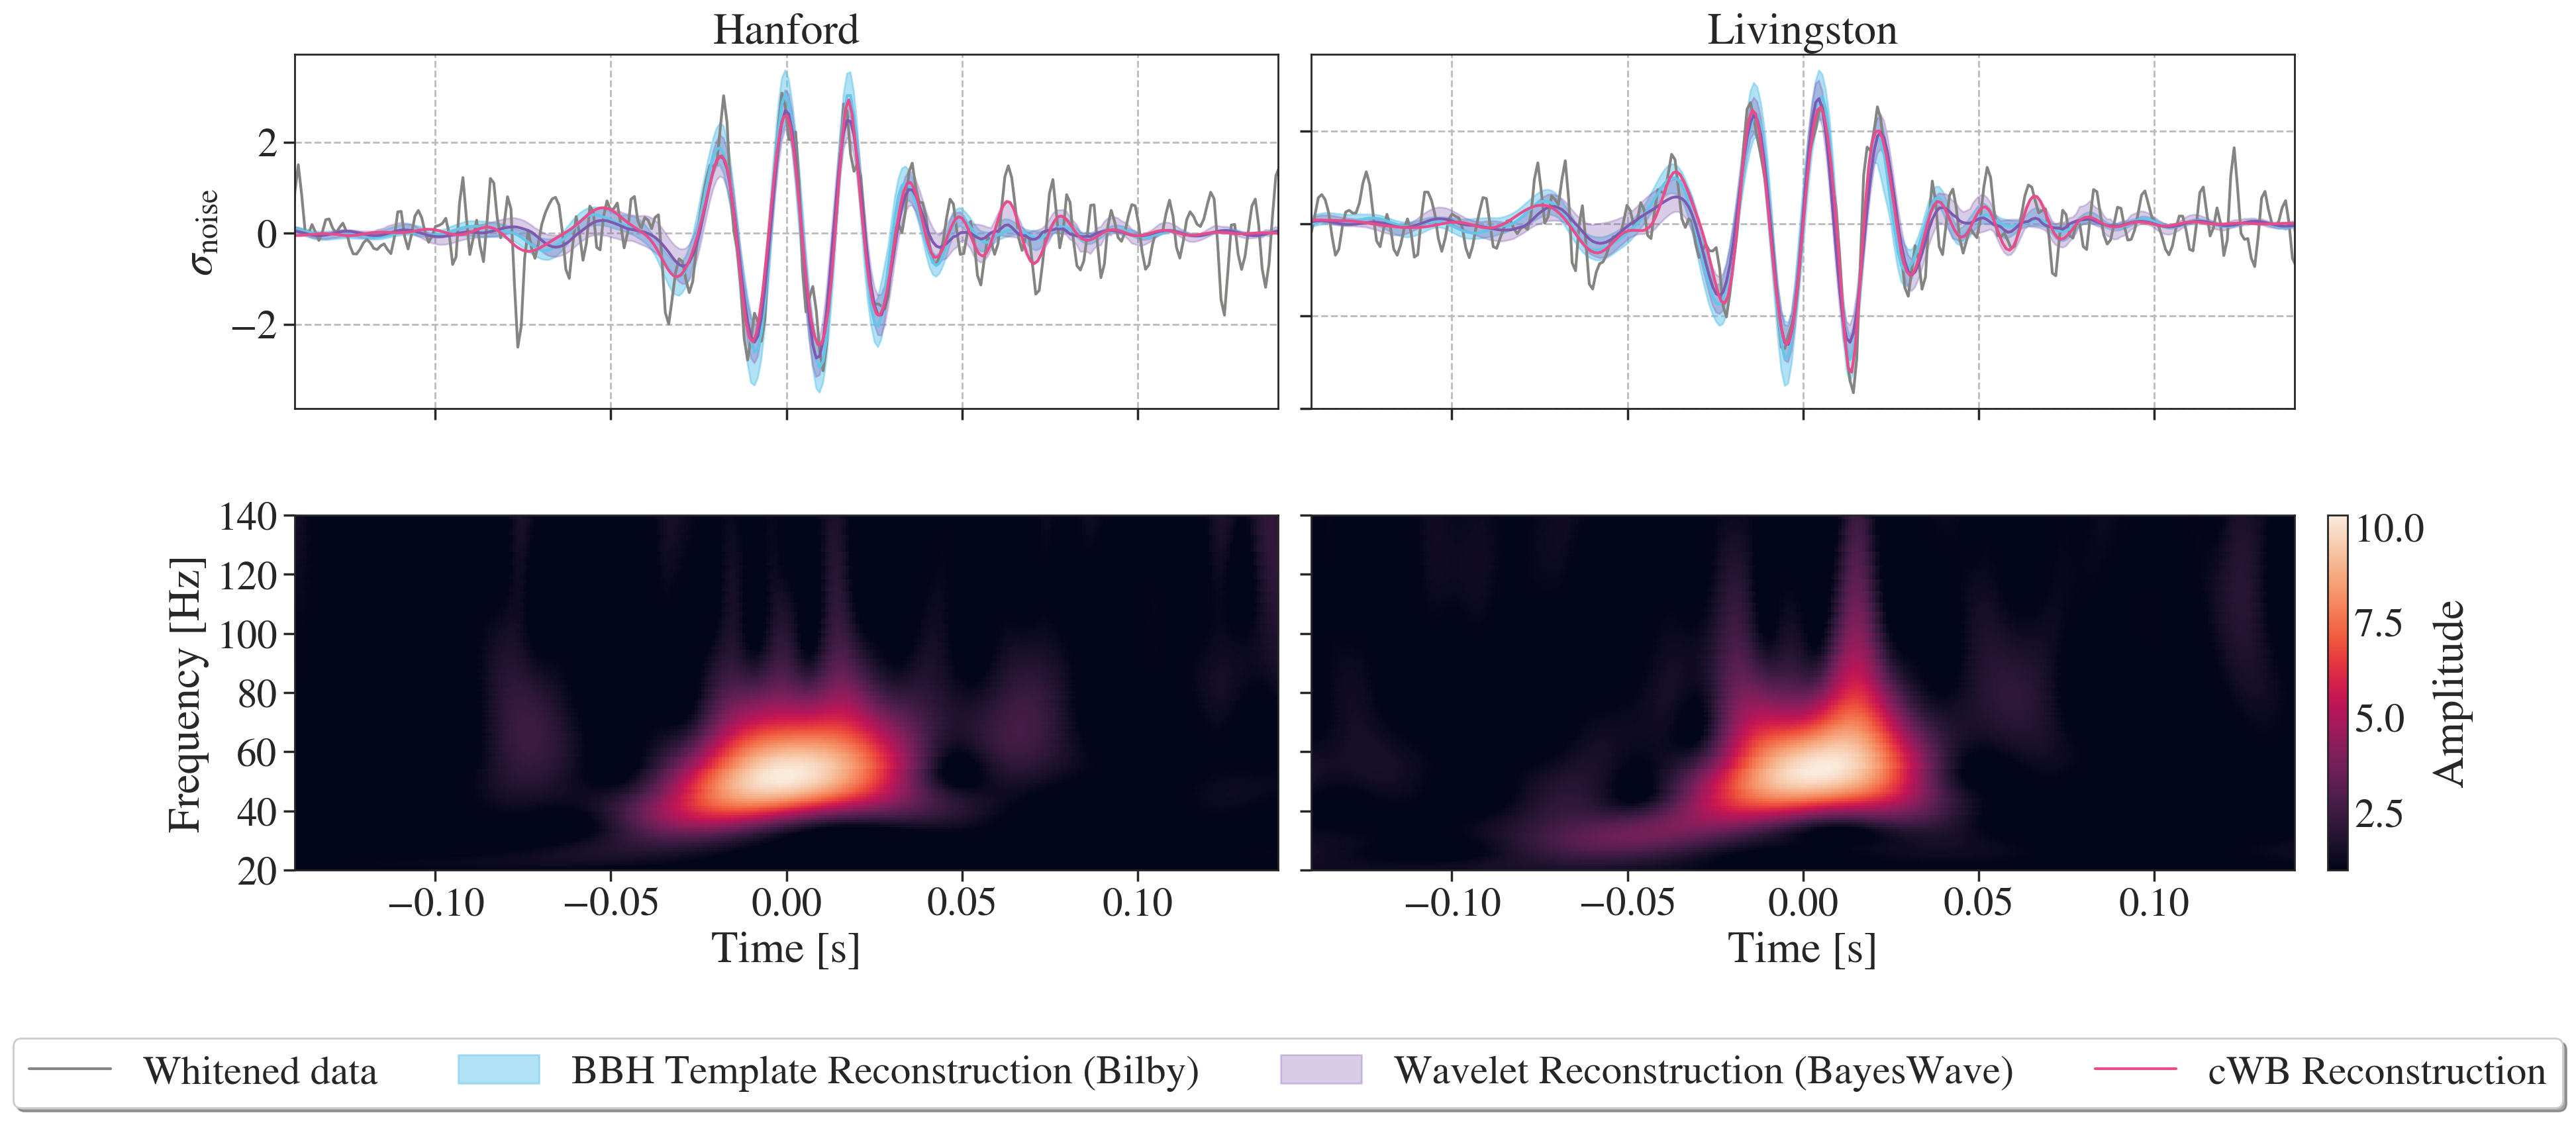

In [21]:
# Create figure with extra column for colorbar

colors = {'whitend_data' : '#848482', 'bayeswave' : '#7F58AF', 'bilby' : '#64C5EB', 'cwb' : '#E84D8A', }
labels = {'H1': 'Hanford',  'L1': 'Livingston',}

fig = pylab.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.02], wspace=0.05, hspace=0.3)

axes = numpy.empty((2, 2), dtype=object)
pcolormesh_handles = []

for col, ifo in enumerate(ifos):
    show_labels = (col == 0)

    # === Top panel ===
    # plot in time domain of whitened data wrt geocentric time, bilby median and 90% interval,
    #BayesWave median reconstruction and 90% interval and cWB maximum-likelihood
  
    if col == 0:
        ax = fig.add_subplot(gs[0, col])
    else:
        ax = fig.add_subplot(gs[0, col], sharex=axes[0, 0])
    axes[0, col] = ax

    ax.plot(whitened_data[ifo]['time'] - geocent_time, whitened_data[ifo]['strain'],
            label='Whitened data' if show_labels else None, color=colors['whitend_data'])

    ax.plot(bilby_summary_data[ifo]['time'] - geocent_time, bilby_summary_data[ifo]['median'],
            color=colors['bilby'])
    ax.set_xlim(-0.14, 0.14)

    ax.fill_between(
        bilby_summary_data[ifo]['time'] - geocent_time,
        bilby_summary_data[ifo]['lower'],
        bilby_summary_data[ifo]['upper'],
        color=colors['bilby'], alpha=0.5,
        label='BBH Template Reconstruction (Bilby)' if show_labels else None
    )

    ax.plot(bw_summary_data[ifo]['time'] - geocent_time, bw_summary_data[ifo]['median'],
            color=colors['bayeswave'])

    ax.fill_between(
        bw_summary_data[ifo]['time'] - geocent_time,
        bw_summary_data[ifo]['lower90'],
        bw_summary_data[ifo]['upper90'],
        color=colors['bayeswave'], alpha=0.3,
        label='Wavelet Reconstruction (BayesWave)' if show_labels else None
    )

    ax.plot(cwb_data[ifo]['time'] - geocent_time, cwb_data[ifo]['amp_cwb_rec'],
            color=colors['cwb'], label='cWB Reconstruction' if show_labels else None)

    if col == 0:
        ax.set_ylabel(r'$\sigma_\mathrm{noise}$')
    ax.set_title(labels[ifo])
    ax.label_outer()

    # === Bottom panel ===
    #spectrogram
    
    if col == 0:
        ax_spec = fig.add_subplot(gs[1, col])
    else:
        ax_spec = fig.add_subplot(gs[1, col], sharex=axes[1, 0], sharey=axes[1, 0])
    axes[1, col] = ax_spec

    decimation_factor = int(sampling_frequency // target_sampling_rate)
    whitened = signal.decimate(whitened_data[ifo]['strain'], decimation_factor)
    times = signal.resample(whitened_data[ifo]['time'], len(whitened)) - geocent_time
    cwt_matrix = signal.cwt(whitened, signal.morlet2, widths=widths, w=w)

    im = ax_spec.pcolormesh(times, cwt_frequencies, numpy.abs(cwt_matrix),
                            vmin=1, shading='auto', cmap='rocket', rasterized=True)
    pcolormesh_handles.append(im)

    if col == 0:
        ax_spec.set_ylabel('Frequency [Hz]')

    ax_spec.set_xlabel('Time [s]')
    ax_spec.set_xlim(-0.14, 0.14)
    ax_spec.set_ylim(20, 140)
    ax_spec.set_yticks(numpy.arange(20, 160, 20))
    ax_spec.label_outer()

# === Add colorbar in dedicated column ===
cax = fig.add_subplot(gs[1, -1])  # Rightmost column in bottom row
cbar = fig.colorbar(pcolormesh_handles[-1], cax=cax, pad=-0.5)
cbar.set_label('Amplitude', rotation=90)
cbar.ax.tick_params(direction='in')

# === Add shared legend ===
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.03),
           fancybox=True, shadow=True, ncol=5)

# === Optional: Save ===
fig.savefig('../Figures/whitened_data_reconstruction_and_qscan.pdf', bbox_inches='tight',dpi=300)